June 29th  
Now try to simulate the Delta7 network using the average recurrent connectivity profile. Unlike the other notebook, this notebook keeps within glomerular connections, but scales them with a different factor compared to between glomerulus connections.

Need to go through and comment, but look at simulate_using_avg_profile_1 for comments

In [216]:
import sys, os, glob
import datetime, time
import pandas as pd
import numpy as np
from numpy import linalg as nla
import scipy.linalg as sla
import numpy.random as nrd

# import scipy.stats as sst

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

gen_fns_dir = os.path.abspath('../shared')
sys.path.append(gen_fns_dir)
from general_file_fns import load_pickle_file, save_pickle_file
import conn_data_analysis_fns as cdaf

curr_date=datetime.datetime.now().strftime('%Y_%m_%d')+'_'
#sd=int((time.time()%1)*(2**31))
# rng = nrd.default_rng(sd)
# print('Seed= ',sd)

In [3]:
data_path = '../delta7_rec_matrices/'
fname = 'delta7_delta7_average_profiles.p'
conn = load_pickle_file(data_path + fname)
print(conn.keys())

dict_keys(['subtype_list', 'neuron_list', 'subtype_idx', 'subtype_boundaries', 'raw_conn_matrix', 'norm_conn_matrix', 'subtype_rec_matrix', 'subtype_avg_input', 'subtype_avg_output', 'left_glom_list', 'right_glom_list', 'left_glom_idx', 'right_glom_idx', 'left_glom_rec_matrix', 'left_glom_avg_input', 'left_glom_avg_output', 'right_glom_rec_matrix', 'right_glom_avg_input', 'right_glom_avg_output', 'glom_avg_input', 'glom_avg_output', 'n_gloms'])


In [4]:
n_gloms = conn['n_gloms']
glom_avg_input = conn['glom_avg_input']
glom_avg_output = conn['glom_avg_output']

In [5]:
glom_avg_input

array([0.15486901, 0.15601156, 0.11619277, 0.08521092, 0.13174347,
       0.08732954, 0.11803541, 0.15060732])

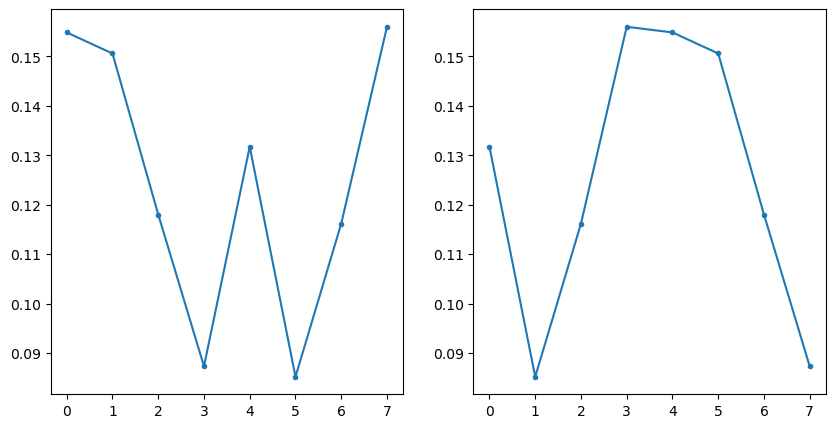

In [6]:
first_col = np.roll(glom_avg_output, -4)
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(glom_avg_output, marker='.')
ax[1].plot(first_col, marker='.')

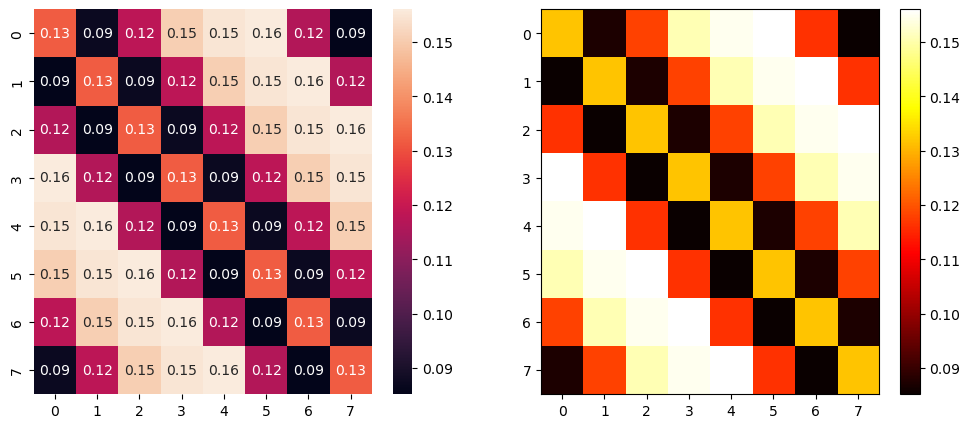

In [7]:
W = sla.circulant(first_col)

fig, ax = plt.subplots(1,2,figsize=(12, 5))
sns.heatmap(W, cmap="rocket", annot=True, fmt=".2f", ax=ax[0])
# ax[0].invert_yaxis()
p = ax[1].imshow(W, aspect='auto', interpolation='nearest', cmap='hot')
fig.colorbar(p, ax=ax[1])



In [8]:
np.allclose(W[:,0], first_col)

True

In [9]:
def relu(x):
    '''Returns 0 if x<0 and x otherwise'''
    return np.maximum(x, 0)

def simulate_network(W, b, x0, time_to_run, dt):
    '''Simulate the network using Euler's method.
    Inputs:
    W:             N x N connectivity matrix
    x0:            N-dimensional initial condition
    time_to_run    how long to simulate for
    dt             simulation step size
    
    Returns an n_times x N matrix containing the simulated system. Note
    that each row is a time point and each column a neuron. 
    '''
    
    n_steps = np.round(time_to_run / dt).astype(int)
    N = W.shape[0] # Number of neurons
    
    # We'll store outputs here
    x = np.zeros((n_steps + 1, N))
    x[0] = np.array(x0)
    
    for i in range(1, n_steps + 1):
        x[i] = x[i-1] + dt * (-x[i-1] + relu(W @ x[i-1] + b))
    
    t = dt * np.arange(n_steps + 1) # Make the time points too for plotting
    return x, t
    

In [10]:
np.diagonal(W)

array([0.13174347, 0.13174347, 0.13174347, 0.13174347, 0.13174347,
       0.13174347, 0.13174347, 0.13174347])

/tmp/ipykernel_2163837/2165428618.py:26: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


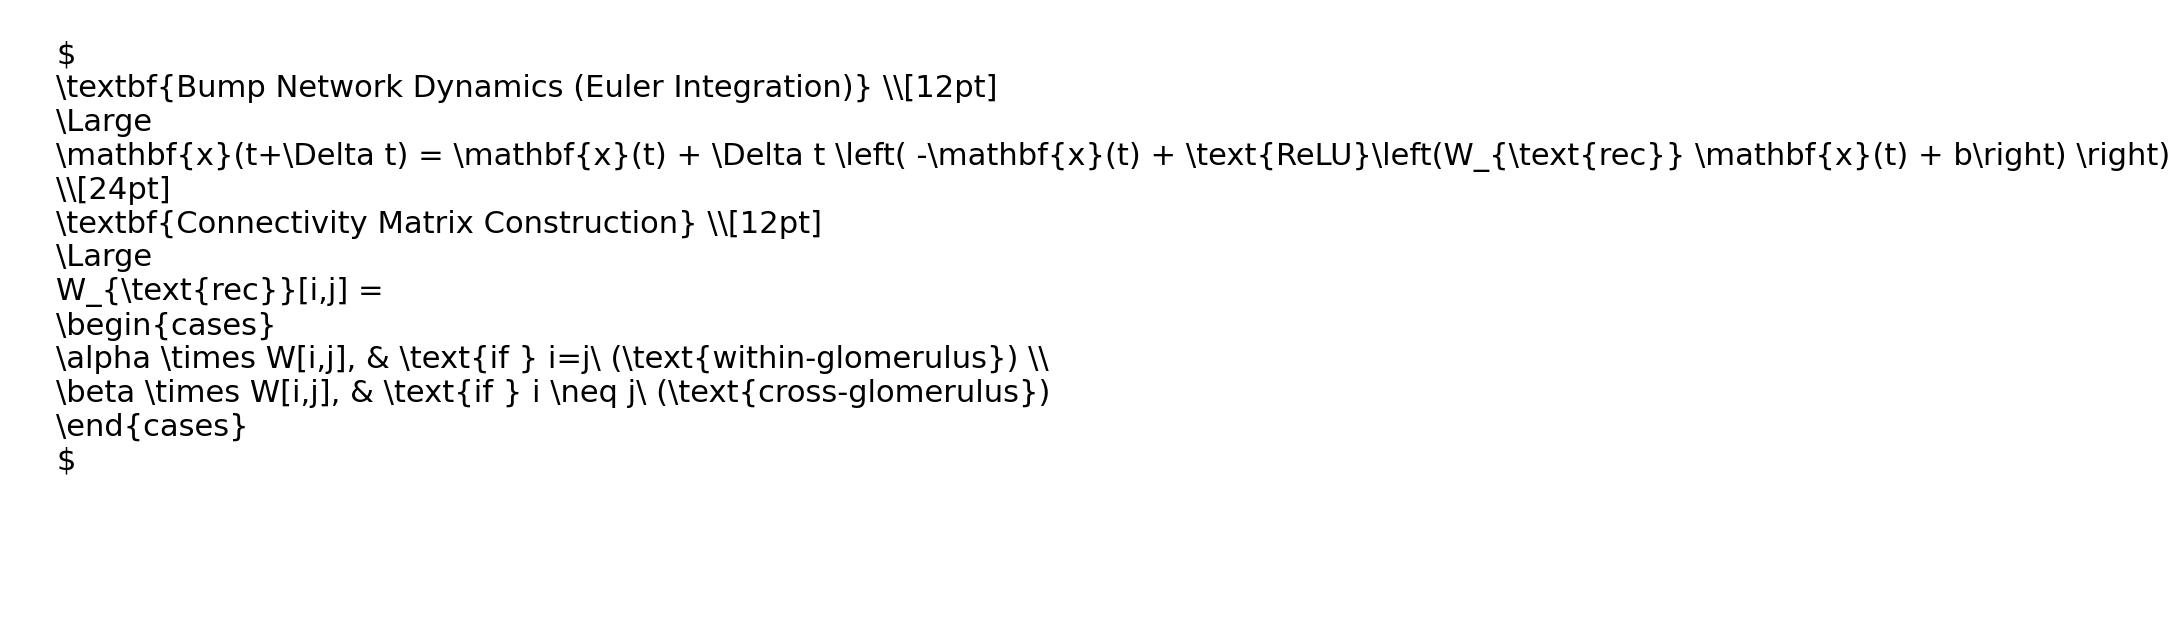

In [277]:
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')  # Hide axes

# Your equations, with $...$ for math mode
equation_text = r"""
\textbf{Bump Network Dynamics (Euler Integration)} \\[12pt]
\Large
\mathbf{x}(t+\Delta t) = \mathbf{x}(t) + \Delta t \left( -\mathbf{x}(t) + \text{ReLU}\left(W_{\text{rec}} \mathbf{x}(t) + b\right) \right)
\\[24pt]
\textbf{Connectivity Matrix Construction} \\[12pt]
\Large
W_{\text{rec}}[i,j] =
\begin{cases}
\alpha \times W[i,j], & \text{if } i=j\ (\text{within-glomerulus}) \\
\beta \times W[i,j], & \text{if } i \neq j\ (\text{cross-glomerulus})
\end{cases}
"""

# Render LaTeX
ax.text(0.05, 0.95, f"${equation_text}$", fontsize=22, va='top', ha='left')

# Save to SVG
plt.tight_layout()
plt.savefig('network_equations.svg', format='svg', bbox_inches='tight')
plt.show()


In [202]:
# alpha converts within glomerulus connection counts to strength, while beta does
# the same for cross glomerular connections. b is a background bias or excitability
alpha = -3
beta = -7
b = 20

W_rec = beta * W
np.fill_diagonal(W_rec, alpha*np.diagonal(W).copy())

In [203]:
# beta = -8, b=25 gives 3 glom wide bump
x0 = np.array([10, 5, 2, 0, 0, 0, 2, 5.])
x0 = np.roll(x0, 3)
time_to_run = 100.
dt = 0.05

x, t = simulate_network(W_rec, b, x0, time_to_run, dt)

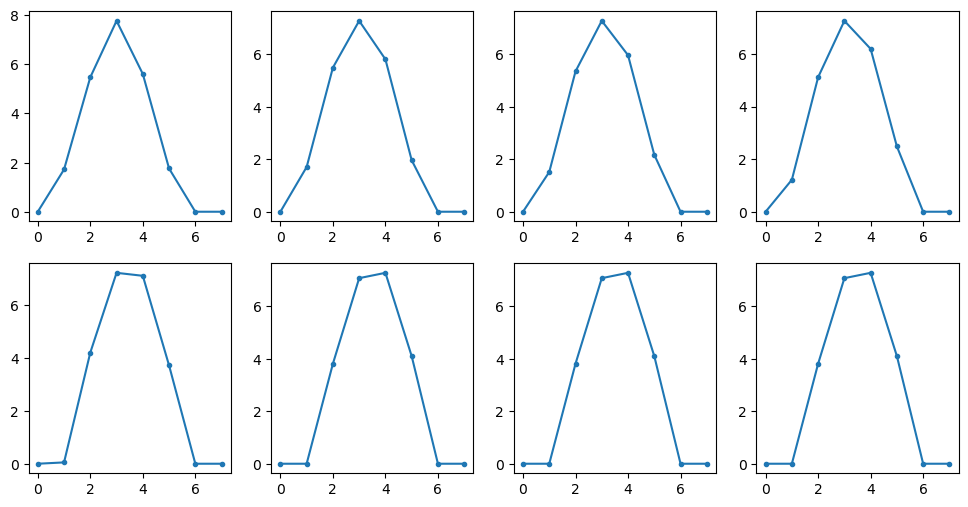

In [204]:
# time_points = np.array([0, 1, 2, 3, 4, 5, 6, 6.9])
time_points = np.array([2, 10, 20, 30, 50, 80, 90, 99])
time_idx = np.round(time_points/dt).astype(int)
fig, axes = plt.subplots(2,4,figsize=(12,6))
for tid, ax in zip(time_idx, axes.flatten()):
    ax.plot(x[tid], marker='.')
    

In [213]:
x.shape

(2001, 8)

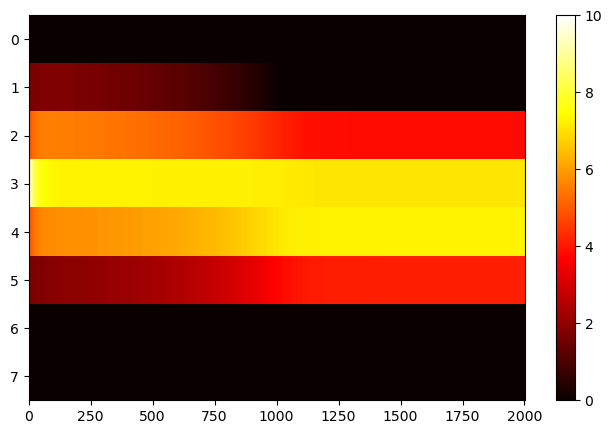

In [214]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
# sns.heatmap(x.T, cmap="rocket")
p = ax.imshow(x.T, aspect='auto', interpolation='nearest', cmap='hot')
fig.colorbar(p, ax=ax)


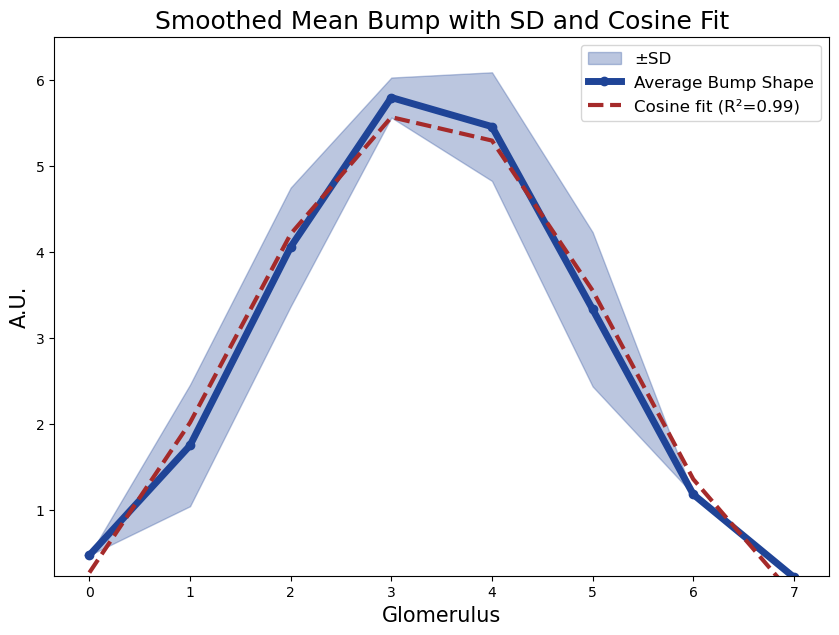

Fit parameters: Amplitude = -2.88, Phase = -0.52 rad, Offset = 2.78
R² of the fit: 0.990


In [240]:
# Define colors
deep_blue = "#1f4497"    # For mean bump
cosine_fit_color = "#A52A2A"  # Different color for cosine fit

# Step 1: Define cosine function
def cosine_func(x, amplitude, phase, offset):
    return amplitude * np.cos(2 * np.pi * (x / 8) - phase) + offset

# Step 2: Compute mean and SD
mean_bump_raw = np.nanmean(x, axis=0)
sd_bump = np.nanstd(x, axis=0)  # SD of raw data
x_vals = np.arange(8)

# Step 3: Smooth the mean bump
mean_bump = gaussian_filter1d(mean_bump_raw, sigma=1)  # Smooth with small sigma (you can adjust)

# Step 4: Fit cosine to smoothed mean bump
initial_guess = [1, 0, 0]
params, _ = curve_fit(cosine_func, x_vals, mean_bump, p0=initial_guess)
fitted_curve = cosine_func(x_vals, *params)

# Step 5: Quantify fit (R²)
r2 = r2_score(mean_bump, fitted_curve)

# Step 6: Plot everything
fig, ax = plt.subplots(figsize=(10, 7))

# Plot smoothed mean ± SD shaded area
ax.fill_between(x_vals, mean_bump - sd_bump, mean_bump + sd_bump,
                color=deep_blue, alpha=0.3, label='±SD')

# Plot smoothed mean bump
ax.plot(x_vals, mean_bump, 'o-', color=deep_blue, linewidth=5, label='Average Bump Shape')

# Plot cosine fit
ax.plot(x_vals, fitted_curve, '--', color=cosine_fit_color, linewidth=3, label=f'Cosine fit (R²={r2:.2f})')

# Labels, title, legend
ax.set_xlabel('Glomerulus', fontsize=15)
ax.set_ylabel('A.U.', fontsize=15)
ax.set_title('Smoothed Mean Bump with SD and Cosine Fit', fontsize=18)
ax.legend(fontsize=12)
ax.set_ylim(0.24,6.5)
#plt.savefig('Bump_shape_deta7_bump_simulaton_smooth.svg', format='svg')
plt.show()

# Print fit parameters
print(f"Fit parameters: Amplitude = {params[0]:.2f}, Phase = {params[1]:.2f} rad, Offset = {params[2]:.2f}")
print(f"R² of the fit: {r2:.3f}")

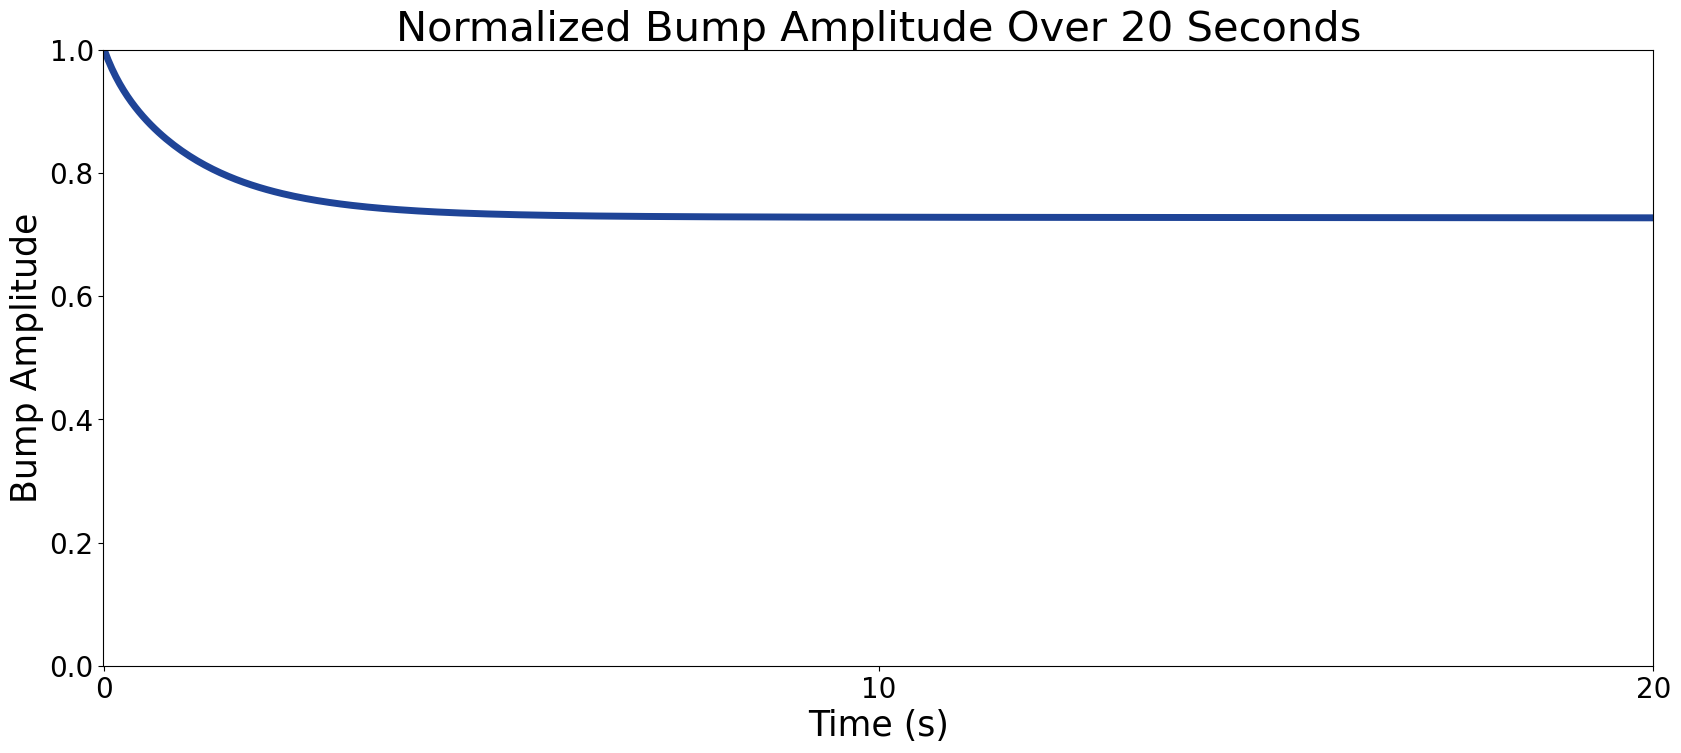

In [210]:

# Step 1: Compute bump amplitude
bump_amplitude = np.nanmax(x[:2000], axis=1) - np.nanmin(x[:2000], axis=1)  # Use first 2000 frames
# Step 2: Normalize amplitude to its value at t = 0
normalized_bump_amplitude = bump_amplitude / bump_amplitude[0]

# Step 3: Create time array (0 to 100 seconds)
time_array = np.linspace(0, 100, len(normalized_bump_amplitude))


# Step 4: Set up plot (your style)
palette = sns.color_palette("tab20b_r", 1)  # Only 1 line
deep_blue = "#1f4497"
plt.figure(figsize=(20, 8))

# Plot normalized, smoothed
plt.plot(
    time_array,
    gaussian_filter1d(normalized_bump_amplitude, sigma=0.1),  # Smoothing
    linewidth=5,
    color=deep_blue
)

# Custom x-ticks every 10 seconds
plt.xticks(
    ticks=np.arange(0, 101, 10),
    labels=np.arange(0, 101, 10, dtype=int),
    fontsize=20
)
plt.yticks(fontsize=20)
plt.xlim(-0.01, 20)
plt.ylim(0, 1)

# Labels and title
plt.xlabel('Time (s)', fontsize=25)
plt.ylabel('Bump Amplitude', fontsize=25)
plt.title('Normalized Bump Amplitude Over 20 Seconds', fontsize=30)
#plt.savefig('Bump_amplitude_deta7_bump_simulaton_smooth.svg', format='svg')
plt.show()

In [153]:
W_rec @ x[-1] + b

array([-2.99800389, -0.31332206,  3.81634157,  7.07997584,  7.28397354,
        4.10615564, -0.24277874, -2.99309271])

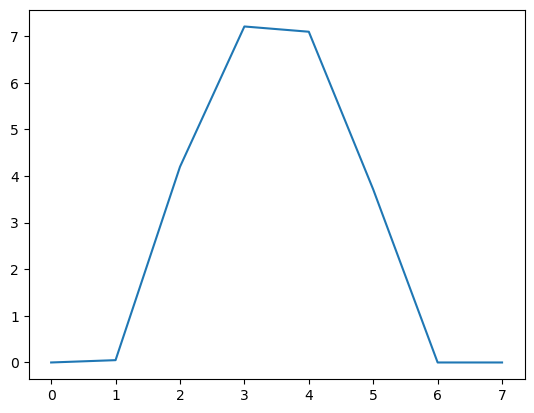

In [155]:
plt.plot(x[1000])